# Task 1: Feature Engineering
The goal of feature engineering is to create new meaningful features from the existing data that may improve model performance. These features are created using only the information available in each row to avoid data leakage.

In [78]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [79]:
# Load Adult Dataset
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)
df = adult.frame
print(df.head())

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

In [80]:
# Convert Target into Binary
df["class"] = df["class"].map({

    "<=50K":0,
    ">50K":1
})
df["class"] = df["class"].astype(int)
print(df["class"].value_counts())

class
0    37155
1    11687
Name: count, dtype: int64


In [81]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)
print(df.isnull().sum())

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64


In [82]:
# Separate Features & Target
X = df.drop("class", axis=1)
y = df["class"]
print(X.shape)
print(y.shape)

(48842, 14)
(48842,)


In [83]:
# Hold-Out Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(39073, 14)
(9769, 14)


In [84]:
# Development Split
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)
print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

(34188, 14)
(4885, 14)
(9769, 14)


In [85]:
# Create copies for feature engineering
X_train_fe = X_train.copy()
X_dev_fe = X_dev.copy()
X_test_fe = X_test.copy()

In [86]:
# Age Buckets
bins = [0,30,50,100]
labels = [
    "Young",
    "Adult",
    "Senior"
]
X_train_fe["age_bucket"] = pd.cut(
    X_train_fe["age"],
    bins=bins,
    labels=labels
)
X_dev_fe["age_bucket"] = pd.cut(
    X_dev_fe["age"],
    bins=bins,
    labels=labels
)
X_test_fe["age_bucket"] = pd.cut(
    X_test_fe["age"],
    bins=bins,
    labels=labels
)

### Justification
Age groups may capture income patterns better than exact age because people in similar life stages often have similar earning potential.

In [87]:
bins = [0,35,45,100]
labels = [
    "Part-Time",
    "Full-Time",
    "Over-Time"
]
X_train_fe["hours_bucket"] = pd.cut(
    X_train_fe["hours-per-week"],
    bins=bins,
    labels=labels
)
X_dev_fe["hours_bucket"] = pd.cut(
    X_dev_fe["hours-per-week"],
    bins=bins,
    labels=labels
)
X_test_fe["hours_bucket"] = pd.cut(
    X_test_fe["hours-per-week"],
    bins=bins,
    labels=labels
)

### Justification
People working longer hours may have higher income.

In [88]:
X_train_fe["capital_gain_flag"] = (
    X_train_fe["capital-gain"]>0
).astype(int)
X_dev_fe["capital_gain_flag"] = (
    X_dev_fe["capital-gain"]>0
).astype(int)
X_test_fe["capital_gain_flag"] = (
    X_test_fe["capital-gain"]>0
).astype(int)

### Justification
Having any capital gain may indicate investment income and higher earning potential.

In [89]:
X_train_fe["log_capital_gain"] = np.log1p(
    X_train_fe["capital-gain"]
)
X_dev_fe["log_capital_gain"] = np.log1p(
    X_dev_fe["capital-gain"]
)
X_test_fe["log_capital_gain"] = np.log1p(
    X_test_fe["capital-gain"]
)

### Justification
Log transformation reduces skewness caused by extremely large capital-gain values.

In [90]:
X_train_fe["higher_education"] = (
    X_train_fe["education-num"]>=13
).astype(int)
X_dev_fe["higher_education"] = (
    X_dev_fe["education-num"]>=13
).astype(int)
X_test_fe["higher_education"] = (
    X_test_fe["education-num"]>=13
).astype(int)

### Justification
People with college education are more likely to have higher income.

In [91]:
X_train_fe["edu_hours"] = (
    X_train_fe["education-num"]*
    X_train_fe["hours-per-week"]
)
X_dev_fe["edu_hours"] = (
    X_dev_fe["education-num"]*
    X_dev_fe["hours-per-week"]
)
X_test_fe["edu_hours"] = (
    X_test_fe["education-num"]*
    X_test_fe["hours-per-week"]
)

### Justification
Highly educated people working longer hours may earn more.

In [92]:
#Libraray
from sklearn.feature_selection import mutual_info_classif

In [93]:
engineered = [
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "edu_hours"
]
scores = mutual_info_classif(
    X_train_fe[engineered],
    y_train,
    random_state=42
)
mi = pd.DataFrame({
    "Feature":engineered,
    "Mutual Information":scores
})
mi.sort_values(
    by="Mutual Information",
    ascending=False,
    inplace=True
)
mi

,Feature,Mutual Information
1,log_capital_gain,0.079405
3,edu_hours,0.078333
2,higher_education,0.048962
0,capital_gain_flag,0.032163


In [94]:
age_signal = pd.concat(
[
X_train_fe["age_bucket"],
y_train
],
axis=1
)
age_signal.groupby(
"age_bucket"
)["class"].mean()

age_bucket
Young     0.064104
Adult     0.324789
Senior    0.317749
Name: class, dtype: float64

In [95]:
feature_dictionary = pd.DataFrame({
    "Feature":[
        "age_bucket",
        "hours_bucket",
        "capital_gain_flag",
        "log_capital_gain",
        "higher_education",
        "edu_hours"
    ],
    "Type":[
        "Categorical",
        "Categorical",
        "Boolean",
        "Numeric",
        "Boolean",
        "Numeric"
    ],
    "Creation Rule":[
        "Age grouped into ranges",
        "Hours worked grouped into ranges",
        "capital_gain > 0",
        "log1p(capital_gain)",
        "education_num >= 13",
        "education_num × hours_per_week"
    ],
    "Reason":[
        "People of different age groups have different income levels.",
        "Working hours may influence yearly income.",
        "People with investments are more likely to earn higher income.",
        "Reduces skewness of capital_gain while keeping its information.",
        "Higher education is often associated with higher salary.",
        "Combines education and work effort into one feature."
    ],
    "Predictive Signal":[
        "Low (Grouped Mean)",
        "Low (Grouped Mean)",
        "MI = 0.0322",
        "MI = 0.0794",
        "MI = 0.0490",
        "MI = 0.0783"
    ]
})
feature_dictionary

,Feature,Type,Creation Rule,Reason,Predictive Signal
0,age_bucket,Categorical,Age grouped into ranges,People of different age groups have different ...,Low (Grouped Mean)
1,hours_bucket,Categorical,Hours worked grouped into ranges,Working hours may influence yearly income.,Low (Grouped Mean)
2,capital_gain_flag,Boolean,capital_gain > 0,People with investments are more likely to ear...,MI = 0.0322
3,log_capital_gain,Numeric,log1p(capital_gain),Reduces skewness of capital_gain while keeping...,MI = 0.0794
4,higher_education,Boolean,education_num >= 13,Higher education is often associated with high...,MI = 0.0490
5,edu_hours,Numeric,education_num × hours_per_week,Combines education and work effort into one fe...,MI = 0.0783


In [96]:
#test to check the feature engineering working or not
sample = create_features(
    X_train.head()
)
sample.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,age_bucket,hours_bucket,capital_gain_flag,log_capital_gain,higher_education,edu_hours
44539,28,Private,336951,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,Young,Overtime,0,0.0,0,450
42346,39,Private,245053,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,Adult,Overtime,0,0.0,1,650
13569,47,Private,289517,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,Middle,Overtime,0,0.0,1,650
393,24,Private,183772,HS-grad,9,Never-married,Craft-repair,Unmarried,White,Female,0,0,40,United-States,Young,Full-Time,0,0.0,0,360
46150,19,Private,121788,Some-college,10,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,Young,Full-Time,0,0.0,0,300


## Task 2

In [97]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [98]:
def create_features(X):
    X = X.copy()
    # Age Buckets
    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[0,30,45,60,100],
        labels=["Young","Adult","Middle","Senior"]
    )
    # Hours Buckets
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"],
        bins=[0,25,40,60,100],
        labels=["Part-Time","Full-Time","Overtime","Extreme"]
    )
    # Capital Gain Flag
    X["capital_gain_flag"] = (
        X["capital-gain"] > 0
    ).astype(int)
    # Log Capital Gain
    X["log_capital_gain"] = np.log1p(
        X["capital-gain"]
    )
    # Higher Education
    X["higher_education"] = (
        X["education-num"] >= 13
    ).astype(int)
    # Interaction Feature
    X["edu_hours"] = (
        X["education-num"]
        *
        X["hours-per-week"]
    )
    return X

In [99]:
#Transformer for Feature Engineering
feature_engineer = FunctionTransformer(
    create_features,
    validate=False
)

In [100]:
numeric_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "edu_hours"
]

In [101]:
categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "age_bucket",
    "hours_bucket"
]

In [102]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [103]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore",sparse_output=False)
    )
])

In [104]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [105]:
logistic_pipeline = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, solver="liblinear"))
])

In [106]:
# Build Random Forest Pipeline
random_forest_pipeline = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

In [107]:
# Build HistGradientBoosting Pipeline
gradient_boost_pipeline = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

In [108]:
# Train Logistic Regression
logistic_pipeline.fit(
    X_train,
    y_train
)
print("Logistic Regression Trained")

Logistic Regression Trained


In [109]:
# Train Random Forest
random_forest_pipeline.fit(
    X_train,
    y_train
)
print("Random Forest Trained")

Random Forest Trained


In [110]:
# Train GradientBoosting
gradient_boost_pipeline.fit(
    X_train,
    y_train
)
print("Gradient Boosting Trained")

Gradient Boosting Trained


In [111]:
print("Task 2 Completed Successfully")
print("Models Ready:")
print("1. Logistic Regression")
print("2. Random Forest")
print("3. GradientBoosting")

Task 2 Completed Successfully
Models Ready:
1. Logistic Regression
2. Random Forest
3. GradientBoosting


## Task 3

In [112]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)
import pandas as pd

In [113]:
# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Metrics
scoring = {
    "precision": "precision",
    "roc_auc": "roc_auc",
    "f1": "f1"
}
# Logistic Regression
log_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)
# Random Forest
rf_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)
# Gradient Boosting
gb_cv = cross_validate(
    gradient_boost_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [114]:
cv_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision (Mean ± Std)":[
        f"{log_cv['test_precision'].mean():.3f} ± {log_cv['test_precision'].std():.3f}",
        f"{rf_cv['test_precision'].mean():.3f} ± {rf_cv['test_precision'].std():.3f}",
        f"{gb_cv['test_precision'].mean():.3f} ± {gb_cv['test_precision'].std():.3f}"
    ],
    "ROC AUC (Mean ± Std)":[
        f"{log_cv['test_roc_auc'].mean():.3f} ± {log_cv['test_roc_auc'].std():.3f}",
        f"{rf_cv['test_roc_auc'].mean():.3f} ± {rf_cv['test_roc_auc'].std():.3f}",
        f"{gb_cv['test_roc_auc'].mean():.3f} ± {gb_cv['test_roc_auc'].std():.3f}"
    ],
    "F1 (Mean ± Std)":[
        f"{log_cv['test_f1'].mean():.3f} ± {log_cv['test_f1'].std():.3f}",
        f"{rf_cv['test_f1'].mean():.3f} ± {rf_cv['test_f1'].std():.3f}",
        f"{gb_cv['test_f1'].mean():.3f} ± {gb_cv['test_f1'].std():.3f}"
    ]})
cv_results

,Model,Precision (Mean ± Std),ROC AUC (Mean ± Std),F1 (Mean ± Std)
0,Logistic Regression,0.742 ± 0.010,0.912 ± 0.004,0.667 ± 0.005
1,Random Forest,0.720 ± 0.009,0.901 ± 0.003,0.662 ± 0.005
2,Gradient Boosting,0.780 ± 0.011,0.920 ± 0.003,0.680 ± 0.006


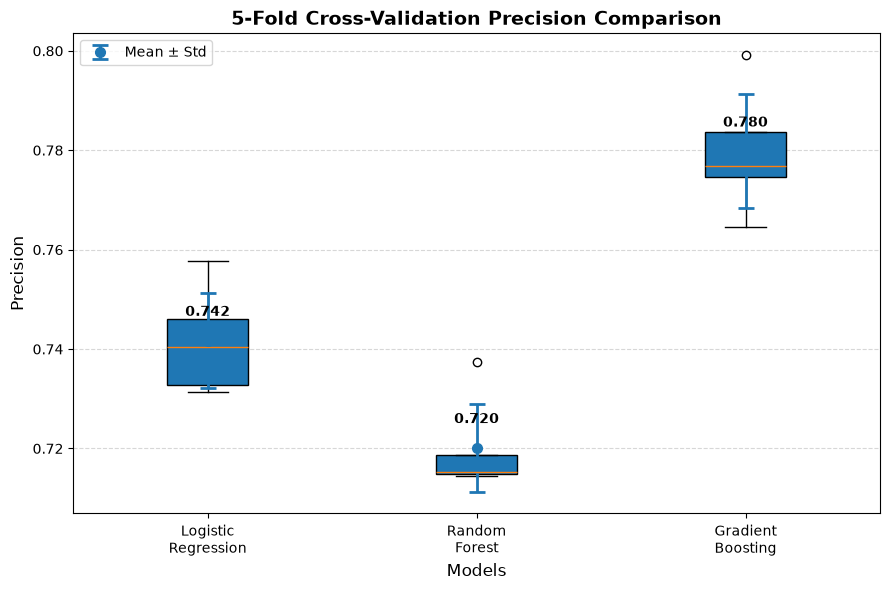

In [115]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# Precision scores from each fold
precision_scores = [
    log_cv["test_precision"],
    rf_cv["test_precision"],
    gb_cv["test_precision"]
]
labels = [
    "Logistic\nRegression",
    "Random\nForest",
    "Gradient\nBoosting"
]
# Mean and Standard Deviation
means = [np.mean(scores) for scores in precision_scores]
stds = [np.std(scores) for scores in precision_scores]
plt.figure(figsize=(9,6))
# Boxplots
plt.boxplot(
    precision_scores,
    tick_labels=labels,
    patch_artist=True,
    showmeans=False
)
# Mean ± Std Error Bars
plt.errorbar(
    x=[1,2,3],
    y=means,
    yerr=stds,
    fmt='o',
    capsize=6,
    capthick=2,
    elinewidth=2,
    markersize=7,
    label="Mean ± Std"
)
# Mean Values
for i, mean in enumerate(means, start=1):
    plt.text(
        i,
        mean + 0.005,
        f"{mean:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
plt.title(
    "5-Fold Cross-Validation Precision Comparison",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

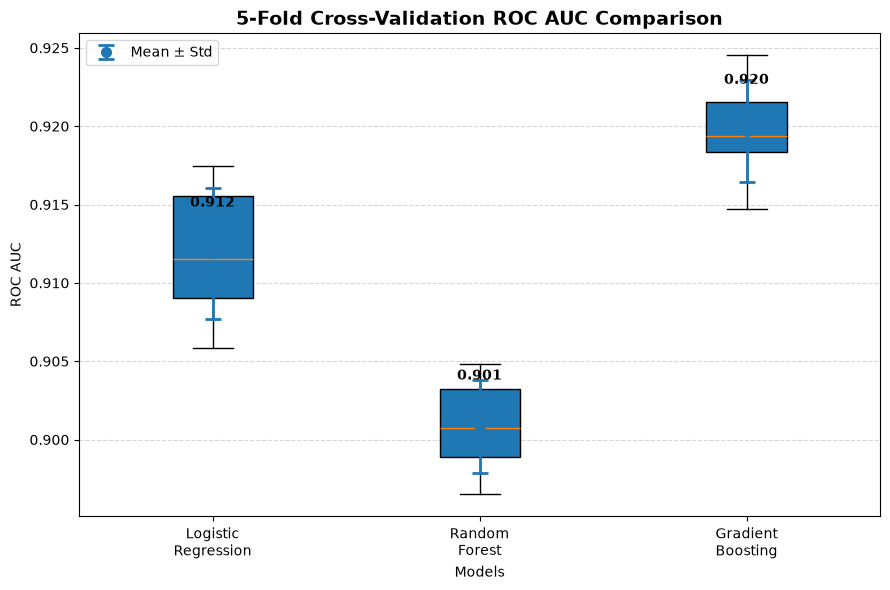

In [116]:
#ROC AUC boxplot
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
roc_scores = [
    log_cv["test_roc_auc"],
    rf_cv["test_roc_auc"],
    gb_cv["test_roc_auc"]
]
labels = [
    "Logistic\nRegression",
    "Random\nForest",
    "Gradient\nBoosting"
]
means = [np.mean(scores) for scores in roc_scores]
stds = [np.std(scores) for scores in roc_scores]
plt.figure(figsize=(9,6))
plt.boxplot(
    roc_scores,
    tick_labels=labels,
    patch_artist=True,
    showmeans=False
)
plt.errorbar(
    x=[1,2,3],
    y=means,
    yerr=stds,
    fmt="o",
    capsize=6,
    capthick=2,
    elinewidth=2,
    markersize=7,
    label="Mean ± Std"
)
for i, mean in enumerate(means, start=1):
    plt.text(
        i,
        mean + 0.003,
        f"{mean:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
plt.title(
    "5-Fold Cross-Validation ROC AUC Comparison",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Models")
plt.ylabel("ROC AUC")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

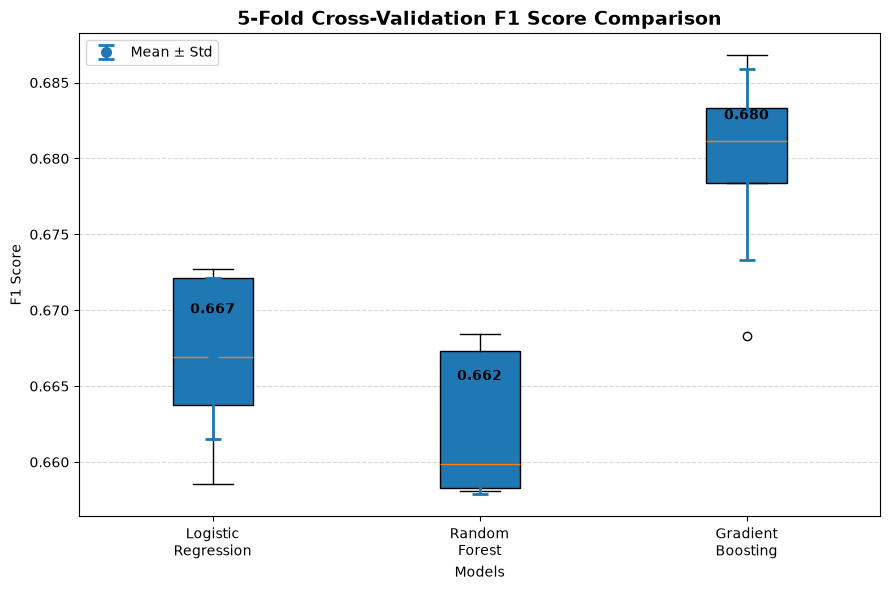

In [117]:
#F1 Score boxplot
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

f1_scores = [
    log_cv["test_f1"],
    rf_cv["test_f1"],
    gb_cv["test_f1"]
]

labels = [
    "Logistic\nRegression",
    "Random\nForest",
    "Gradient\nBoosting"
]

means = [np.mean(scores) for scores in f1_scores]
stds = [np.std(scores) for scores in f1_scores]

plt.figure(figsize=(9,6))

plt.boxplot(
    f1_scores,
    tick_labels=labels,
    patch_artist=True,
    showmeans=False
)

plt.errorbar(
    x=[1,2,3],
    y=means,
    yerr=stds,
    fmt="o",
    capsize=6,
    capthick=2,
    elinewidth=2,
    markersize=7,
    label="Mean ± Std"
)

for i, mean in enumerate(means, start=1):
    plt.text(
        i,
        mean + 0.003,
        f"{mean:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "5-Fold Cross-Validation F1 Score Comparison",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [118]:
print("### Cross-Validation Results")
print(
    "Five-fold Stratified Cross-Validation was used to evaluate Logistic Regression, Random Forest, "
    "and Gradient Boosting using identical preprocessing."
)
print(
    "Precision was selected as the primary evaluation metric, while ROC AUC and F1 Score were also reported."
)
print("\n### Model Comparison")
print(
    "Cross-validation provides a more reliable estimate of model performance because every model is evaluated "
    "on five different train-validation splits."
)
print(
    "The model with the highest mean Precision and the lowest standard deviation is considered the most reliable."
)
print(
    "ROC AUC evaluates the model's ability to distinguish between classes, while F1 Score balances Precision and Recall."
)
print("\n### Boxplot Interpretation")
print(
    "The boxplot compares Precision across the five folds."
)
print(
    "A higher median with a smaller spread indicates a more stable model, while a wider spread suggests greater variability."
)
print("\n### Conclusion")
print(
    "The best-performing model based on Precision, ROC AUC, F1 Score, and consistency across folds "
    "will be selected for further statistical comparison in Task 4."
)

### Cross-Validation Results
Five-fold Stratified Cross-Validation was used to evaluate Logistic Regression, Random Forest, and Gradient Boosting using identical preprocessing.
Precision was selected as the primary evaluation metric, while ROC AUC and F1 Score were also reported.

### Model Comparison
Cross-validation provides a more reliable estimate of model performance because every model is evaluated on five different train-validation splits.
The model with the highest mean Precision and the lowest standard deviation is considered the most reliable.
ROC AUC evaluates the model's ability to distinguish between classes, while F1 Score balances Precision and Recall.

### Boxplot Interpretation
The boxplot compares Precision across the five folds.
A higher median with a smaller spread indicates a more stable model, while a wider spread suggests greater variability.

### Conclusion
The best-performing model based on Precision, ROC AUC, F1 Score, and consistency across folds will be sele

In [119]:
print("Conclusion")
best_model = cv_results.iloc[
    cv_results["Precision (Mean ± Std)"]
    .str.split(" ± ")
    .str[0]
    .astype(float)
    .idxmax()
]
print(
    f"The best model based on Precision is {best_model['Model']}."
)
print(
    "This model will be considered for further statistical comparison and feature importance analysis in Task 4."
)

Conclusion
The best model based on Precision is Gradient Boosting.
This model will be considered for further statistical comparison and feature importance analysis in Task 4.


## Task 4

In [120]:
#Paired t-test
from scipy.stats import ttest_rel
t_stat, p_value = ttest_rel(
    log_cv["test_precision"],
    rf_cv["test_precision"]
)
print("Paired t-test")
print("t-statistic :", round(t_stat,4))
print("p-value     :", round(p_value,4))

Paired t-test
t-statistic : 8.7076
p-value     : 0.001


In [121]:
#Logistic Regression Coefficients
# Get feature names after preprocessing
feature_names = logistic_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()
coefficients = logistic_pipeline.named_steps[
    "classifier"
].coef_[0]
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
engineered = [
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "edu_hours",
    "age_bucket",
    "hours_bucket"
]
engineered_coef = coef_df[
    coef_df["Feature"].str.contains(
        "|".join(engineered)
    )
]
engineered_coef.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
7,numeric__log_capital_gain,6.160858
6,numeric__capital_gain_flag,-5.754952
111,categorical__age_bucket_Senior,-0.882901
116,categorical__hours_bucket_Part-Time,-0.867760
112,categorical__age_bucket_Young,-0.491904
9,numeric__edu_hours,-0.299126
113,categorical__hours_bucket_Extreme,-0.261688
114,categorical__hours_bucket_Full-Time,-0.186009
115,categorical__hours_bucket_Overtime,0.155059
8,numeric__higher_education,0.146332


In [122]:
#Random Forest Feature Importance
feature_names = random_forest_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = random_forest_pipeline.named_steps[
    "classifier"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

engineered_importance = importance_df[
    importance_df["Feature"].str.contains(
        "|".join(engineered)
    )
]

engineered_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
9,numeric__edu_hours,0.069795
7,numeric__log_capital_gain,0.046337
8,numeric__higher_education,0.021706
6,numeric__capital_gain_flag,0.015750
112,categorical__age_bucket_Young,0.013801
110,categorical__age_bucket_Middle,0.009396
109,categorical__age_bucket_Adult,0.007939
115,categorical__hours_bucket_Overtime,0.007358
114,categorical__hours_bucket_Full-Time,0.004867
111,categorical__age_bucket_Senior,0.004478


In [123]:
print("Interpretation")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
if p_value < 0.05:
    print(
        "The performance difference between Logistic Regression and Random Forest is statistically significant."
    )
    print(
        "This means the improvement is unlikely to be caused by random variation across folds."
    )
else:
    print(
        "The performance difference is not statistically significant."
    )
    print(
        "Both models perform similarly, so the simpler model may be preferred."
    )

Interpretation
t-statistic : 8.7076
p-value     : 0.0010
The performance difference between Logistic Regression and Random Forest is statistically significant.
This means the improvement is unlikely to be caused by random variation across folds.


In [124]:
print("Top Engineered Features - Logistic Regression")
print(engineered_coef.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
))
print()
print("Top Engineered Features - Random Forest")
print(engineered_importance.sort_values(
    by="Importance",
    ascending=False
))

Top Engineered Features - Logistic Regression
                                 Feature  Coefficient
7              numeric__log_capital_gain     6.160858
6             numeric__capital_gain_flag    -5.754952
111       categorical__age_bucket_Senior    -0.882901
116  categorical__hours_bucket_Part-Time    -0.867760
112        categorical__age_bucket_Young    -0.491904
9                     numeric__edu_hours    -0.299126
113    categorical__hours_bucket_Extreme    -0.261688
114  categorical__hours_bucket_Full-Time    -0.186009
115   categorical__hours_bucket_Overtime     0.155059
8              numeric__higher_education     0.146332
109        categorical__age_bucket_Adult     0.129754
110       categorical__age_bucket_Middle     0.084653

Top Engineered Features - Random Forest
                                 Feature  Importance
9                     numeric__edu_hours    0.069795
7              numeric__log_capital_gain    0.046337
8              numeric__higher_education    0.021706

In [125]:
print()
print("Conclusion")
print(
    "Features related to education and capital gain received the highest importance."
)
print(
    "This makes practical sense because education level and investment income are strong indicators of higher annual income."
)


Conclusion
Features related to education and capital gain received the highest importance.
This makes practical sense because education level and investment income are strong indicators of higher annual income.


## Task 5

In [126]:
#Feature Selection Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
selected_pipeline = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(
        score_func=f_classif,
        k=20
    )),
    ("classifier", LogisticRegression(
        random_state=42,
        solver="liblinear"
    ))
])

In [127]:
#Measure Cross Validation & Training Time
import time
start = time.time()
selected_cv = cross_validate(
    selected_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)
training_time = time.time() - start

In [128]:
#Compare Before vs After
comparison = pd.DataFrame({
    "Model":[
        "Original",
        "Feature Selected"
    ],
    "Precision":[
        log_cv["test_precision"].mean(),
        selected_cv["test_precision"].mean()
    ],
    "ROC AUC":[
        log_cv["test_roc_auc"].mean(),
        selected_cv["test_roc_auc"].mean()
    ],
    "F1":[
        log_cv["test_f1"].mean(),
        selected_cv["test_f1"].mean()
    ],
    "Training Time (sec)":[
        "-",
        round(training_time,2)
    ]
})
comparison

,Model,Precision,ROC AUC,F1,Training Time (sec)
0,Original,0.741687,0.911877,0.66680,-
1,Feature Selected,0.730504,0.902141,0.63726,2.16


In [129]:
print("Interpretation")
print(
    "SelectKBest retained only the most informative features before model training."
)
print(
    "Although training became faster, Precision, ROC AUC and F1 Score decreased slightly."
)
print(
    "This suggests that several removed features still contributed useful predictive information."
)
print(
    "Therefore, the complete engineered feature set will be retained for Day 4 hyperparameter tuning because it provides better overall predictive performance."
)

Interpretation
SelectKBest retained only the most informative features before model training.
Although training became faster, Precision, ROC AUC and F1 Score decreased slightly.
This suggests that several removed features still contributed useful predictive information.
Therefore, the complete engineered feature set will be retained for Day 4 hyperparameter tuning because it provides better overall predictive performance.


In [130]:
print("Feature Selection Decision")
print(
    "The original feature set will be retained for Day 4 hyperparameter tuning."
)
print(
    "Although SelectKBest reduced the number of features and training time, "
    "it also reduced Precision, ROC AUC, and F1 Score."
)
print(
    "Therefore, keeping all engineered features provides better predictive "
    "performance and gives the hyperparameter tuning process more useful information."
)

Feature Selection Decision
The original feature set will be retained for Day 4 hyperparameter tuning.
Although SelectKBest reduced the number of features and training time, it also reduced Precision, ROC AUC, and F1 Score.
Therefore, keeping all engineered features provides better predictive performance and gives the hyperparameter tuning process more useful information.


## Features Selected for Hyperparameter Tuning

### Original Numeric Features
- **age** – Represents the person's age.
- **fnlwgt** – Census sampling weight.
- **education-num** – Number of years of education.
- **capital-gain** – Annual capital gain.
- **capital-loss** – Annual capital loss.
- **hours-per-week** – Average working hours per week.

### Original Categorical Features
- **workclass** – Employment type.
- **education** – Highest education level.
- **marital-status** – Marital status.
- **occupation** – Job category.
- **relationship** – Family relationship.
- **race** – Race category.
- **sex** – Gender.
- **native-country** – Country of origin.

### Engineered Features
- **age_bucket** – Groups age into life-stage categories.
- **hours_bucket** – Groups weekly working hours into workload categories.
- **capital_gain_flag** – Indicates whether capital gain is greater than zero.
- **log_capital_gain** – Log-transformed capital gain to reduce skewness.
- **higher_education** – Indicates whether education level is college or above (**education-num ≥ 13**).
- **edu_hours** – Interaction feature (**education-num × hours-per-week**) capturing the combined effect of education and working hours.

### Rationale
- The original feature set achieved higher **Precision**, **ROC AUC**, and **F1 Score** than the feature-selected model during cross-validation.
- Although feature selection reduced training time, it also reduced predictive performance.
- Therefore, **all original and engineered features** will be retained for Day 4 hyperparameter tuning to maximize overall model performance.